In [1]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import time

In [2]:
X_test = pd.read_csv('X_test.csv')
X_train_full = pd.read_csv('X_train.csv')
y_train_full = pd.read_csv('y_train.csv')

# Para tratar de mejorar overfitting, ya del principio spliteo la data

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42
)

In [3]:
#Antes que nada, un codigo general para chequear distintas variables de una 
#Pongo lo de timear para algo q voy a probar dsp

start_time = time.perf_counter()

selected_features = ['fage', 'mage']

X_tr_test = pd.get_dummies(X_tr[selected_features], drop_first=True) #mini dataset con las features q elegí, y get_dummies hace eso de poner 0 o 1 a strings. 
X_val_test = pd.get_dummies(X_val[selected_features], drop_first=True) #lo mismo para el validation set


model = LinearRegression()
model.fit(X_tr_test, y_tr)

#O sea, a mi me parece mas logico que si yo entreno con un set de features, el mae y el r2 se calculen sobre lo que dejé, onda lo que 
#no es de training

predictions = model.predict(X_val_test)
mae = mean_absolute_error(y_val, predictions)
r2 = r2_score(y_val, predictions)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Features: {selected_features}")
print(f"MAE: {mae:.4f}")
print(f"r²: {r2:.4f}")
print(f"Execution time: {execution_time:.4f} seconds")

Features: ['fage', 'mage']
MAE: 0.8358
r²: -0.0282
Execution time: 0.0444 seconds


In [4]:
#ok. Tarda 20 milisegundos puedo simplemente ver que combinacion de las 2^9-1 que hay da menor MAE son tipo 10s
# blame the game not the player xD

def filter(features, X_fit, X_other): #Me conviene tener esto porque siempre voy a tener que hacer lo mismo para tr y val. 
    """
    Transforma strings en "True/False" y filtra arrays dado columnas
    """
    X_fit_filtered = pd.get_dummies(X_fit[list(features)], drop_first=True)
    X_other_filtered = pd.get_dummies(X_other[list(features)], drop_first=True)
    X_other_filtered = X_other_filtered.reindex(columns=X_fit_filtered.columns, fill_value=0)
    return X_fit_filtered, X_other_filtered


def evaluate_features(features, X_tr, y_tr, X_val, y_val):
    """
    Fitea una linear dado unas features al X_tr y y_tr, y calcula el mae y r2 en el X_val y y_val
    """
    X_tr_enc, X_val_enc = filter(features, X_tr, X_val)

    model = LinearRegression()
    model.fit(X_tr_enc, y_tr)
    preds_val = model.predict(X_val_enc)

    mae = mean_absolute_error(y_val, preds_val)
    r2 = r2_score(y_val, preds_val)
    return mae, r2

#sanitycheck

In [5]:

selected_features = ['fage', 'mage']
mae, r2 = evaluate_features(selected_features, X_tr, y_tr, X_val, y_val)


print(f"Features: {selected_features}")
print(f"Held-out MAE: {mae:.4f}")
print(f"Held-out r2: {r2:.4f}")
print(f"Execution time: {execution_time:.4f} seconds")

Features: ['fage', 'mage']
Held-out MAE: 0.8358
Held-out r2: -0.0282
Execution time: 0.0444 seconds


# Fuerza bruta con linear regression

Bueno ahora si, voy a hacer fuerza bruta sobre todas las posibles combinaciones defeatures

In [6]:
def evaluate_all_feature_subsets(X_tr, y_tr, X_val, y_val):
    all_features = np.array(['fage', 'mage', 'mature', 'visits', 'gained', 'sex', 'habit', 'marital', 'whitemom'])
    n = len(all_features)
    masks = np.array(list(product([0, 1], repeat=n)))[1:]  # esto es una mascara para poder agarrar todas las 2^n-1 combinaciones de all_features

    results = []
    for mask in masks:
        feats = all_features[mask.astype(bool)]
        mae, r2 = evaluate_features(feats, X_tr, y_tr, X_val, y_val)
        results.append({'features': feats, 'mae': mae, 'r2': r2})
    return pd.DataFrame(results).sort_values(by='mae').reset_index(drop=True)


results_df = evaluate_all_feature_subsets(X_tr, y_tr, X_val, y_val)

print("Top 10 combos:")
print(results_df.head(10))

Top 10 combos:
                                          features       mae        r2
0          [fage, mage, visits, marital, whitemom]  0.825491  0.002360
1                   [fage, mage, visits, whitemom]  0.825730  0.002219
2                [mage, visits, marital, whitemom]  0.825792  0.004061
3                         [mage, visits, whitemom]  0.825983  0.003781
4                 [mage, visits, gained, whitemom]  0.826831 -0.023562
5           [fage, mage, visits, gained, whitemom]  0.826853 -0.025113
6        [mage, visits, gained, marital, whitemom]  0.826864 -0.023151
7  [fage, mage, visits, gained, marital, whitemom]  0.826907 -0.024907
8                  [fage, mage, marital, whitemom]  0.827700  0.000273
9                        [mage, marital, whitemom]  0.828013  0.001067


# Delirio absoluto

El codigo de arriba esta bueno, pero mi problema con el codigo es que _qué pasa si justo la combinacion de features que elegí le gusta al split que generó la seed_? es decir, si elijo otra seed, la mejor combinacion es otra?

Bueno para resolver esto voy a generar muchos splits distintos y ver que combinacion de features se mantiene mas seguido en el top 3 o top 10 o lo que sea, la idea es que si una combo de features es siempre muy buena, entonces probablemente sea la mejor q no overfittee

Ojo que esto si tarda mucho, es maso 8/10s cada split, asi que si hago 10 splits distintos ya es casi 2 minutos. 

In [16]:
#Esto si que tarda eh! bajar n_repeats asi tarda menos xD  VER ABAJO!!


#Bueno para que sea justo, la idea es correr la funcion del principio train_test_split muchas veces pero con distintas seeds O sea genero
# un numero aleatorio de seeds xD. 
def get_best_combinations_repeated(X_data, y_data, n_repeats, split_frac=0.20, seed=42):

    rng = np.random.default_rng(seed) # No estoy seguro de si es prudente poner la seed aca o no 

    all_run_results = []

    for run in range(n_repeats):
        run_seed = int(rng.integers(0, 1e6))

        X_tr_r, X_val_r, y_tr_r, y_val_r = train_test_split(
            X_data, y_data, test_size=split_frac, random_state=run_seed
        )

        run_df = evaluate_all_feature_subsets(X_tr_r, y_tr_r, X_val_r, y_val_r)
        run_df['features'] = run_df['features'].apply(lambda f: ", ".join(f))
        run_df['run'] = run
        all_run_results.append(run_df)

    return pd.concat(all_run_results, ignore_index=True)

repeated_results = get_best_combinations_repeated(X_train_full, y_train_full, n_repeats=50)


In [ ]:
top_per_run = repeated_results.groupby('run', group_keys=False).apply(lambda d: d.nsmallest(5, 'mae'))
top_counts = top_per_run['features'].value_counts()

print("Combo de features que mas veces apareció en el top 5")
print(top_counts.head(10))

Combo de features que mas veces apareció en el top 10
features
fage, gained, sex, habit, whitemom                             8
fage, mature, gained, sex, habit, whitemom                     5
fage, gained, sex, habit, marital, whitemom                    5
mage, mature, gained, sex, whitemom                            5
mature, gained, sex                                            4
mage, gained, sex, habit, marital, whitemom                    4
mage, mature, visits, gained, sex, whitemom                    4
fage, visits, gained, sex, habit, marital, whitemom            4
fage, mature, visits, gained, sex, habit, marital, whitemom    4
mage, mature, gained, sex, habit, marital, whitemom            3
Name: count, dtype: int64


Interesante esto, antes hice el codigo probando validando mae y r2 contra el set de entrenamiento, o sea nunca spliteando
y llegaba a: 
 ['fage', 'gained', 'sex', 'habit', 'whitemom'] 
como ganador absoluto

Ahora salio 

[fage, mature, gained, sex, habit, whitemom]    como ganador con 10 victorias en n=50

y [fage, gained, sex, habit, whitemom] con 8. Si hay algo que explica los datos es esta combo, tampoco hay tanta diferencia entre las dos la verdad solo incluir 'mature' o no. 

El tema es que para mi no tiene mucho sentido, gained es claramente logico como predictor porque evidentemente si la mina engorda mas uno espera que el bebe pesa mas xddd. No se no soy biologo. 

fage y mage tambien tienen sentido, que se yo puede tener algo que ver. Pero no entiendo pr que "mature" seria mejor predictor que "mage" No creo que la naturaleza magicamente favorezca a tener o no tener 35 años. 

Bueno entonces mi working theory es que el set mas importante es fage, gained, sex, habit y whitemom. Quizas despues cuando lo pruebe en X_test

In [9]:
#Para ver los numeros
print(evaluate_features(['fage','gained','sex','habit','whitemom'], X_train_full, y_train_full,X_train_full, y_train_full))

print(evaluate_features(['fage','mature','gained','sex','habit','whitemom'], X_train_full, y_train_full,X_train_full, y_train_full))

(0.8821243182546038, 0.07249509171166535)
(0.8825925354808881, 0.0769991452145955)


Bue qcyo no es una locura. Supuestamente a Chatgpt pro le dio MAE = 1.07 Y R2 =0.099 sobre el y_test (que yo no tengo) asi que bueno

In [10]:
#Ok este codigo no es mío, Simplemente le mandé mi codigo a claude y le dije "hacelo lo mas rapido q se pueda"

#No tengo ni idea de que pasa acá pero es rapidisimo! 

import numpy as np, pandas as pd, time
from itertools import product
from sklearn.model_selection import train_test_split

def get_best_combinations_repeated(X_data, y_data, n_repeats, split_frac=0.20, seed=42,
        all_features=('fage','mage','mature','visits','gained','sex','habit','marital','whitemom')):
    all_features = list(all_features)

    blocks, feat_cols, p = [], [], 0
    for f in all_features:
        d = pd.get_dummies(X_data[[f]], drop_first=True)
        blocks.append(np.asarray(d, dtype=np.float64))
        feat_cols.append(np.arange(1 + p, 1 + p + d.shape[1])); p += d.shape[1]
    n = len(X_data)
    Xa = np.empty((n, p + 1)); Xa[:, 0] = 1.0; Xa[:, 1:] = np.hstack(blocks)
    mu, sd = Xa[:, 1:].mean(0), Xa[:, 1:].std(0); sd[sd == 0] = 1.0
    Xa[:, 1:] = (Xa[:, 1:] - mu) / sd            
    y = np.asarray(y_data, dtype=np.float64).ravel()
    assert np.isfinite(Xa).all() and np.isfinite(y).all(), "hay NaNs en los datos"

    masks = np.array(list(product([0, 1], repeat=len(all_features))), dtype=bool)[1:]
    names = np.array([", ".join([f for f, m in zip(all_features, k) if m]) for k in masks], dtype=object)
    groups = {}
    for i, msk in enumerate(masks):
        cols = np.concatenate([[0]] + [feat_cols[j] for j in np.flatnonzero(msk)])
        g = groups.setdefault(len(cols), ([], [])); g[0].append(i); g[1].append(cols)
    groups = {k: (np.array(a), np.array(b)) for k, (a, b) in groups.items()}

    idx, S = np.arange(n), len(masks)
    rng = np.random.default_rng(seed)
    mae_out, r2_out = np.empty((n_repeats, S)), np.empty((n_repeats, S))

    for run in range(n_repeats):
        run_seed = int(rng.integers(0, 1e6))
        itr, iva = train_test_split(idx, test_size=split_frac, random_state=run_seed)
        Xtr, Xva, ytr, yva = Xa[itr], Xa[iva], y[itr], y[iva]
        G, b = Xtr.T @ Xtr, Xtr.T @ ytr
        ss_tot = np.sum((yva - yva.mean()) ** 2)
        for _, (rows, C) in groups.items():
            Gs, bs = G[C[:, :, None], C[:, None, :]], b[C]
            try:
                beta = np.linalg.solve(Gs, bs[:, :, None])[:, :, 0]
            except np.linalg.LinAlgError:
                beta = (np.linalg.pinv(Gs) @ bs[:, :, None])[:, :, 0]
            B = np.zeros((len(rows), Xa.shape[1])); np.put_along_axis(B, C, beta, axis=1)
            res = B @ Xva.T - yva                       # (subsets, n_val) at once
            mae_out[run, rows] = np.abs(res).mean(1)
            r2_out[run, rows] = 1.0 - (res * res).sum(1) / ss_tot

    order = np.argsort(mae_out, axis=1, kind='stable')   
    return pd.DataFrame({'features': np.concatenate([names[o] for o in order]),
                         'mae': np.take_along_axis(mae_out, order, 1).ravel(),
                         'r2':  np.take_along_axis(r2_out,  order, 1).ravel(),
                         'run': np.repeat(np.arange(n_repeats), S)})

t = time.perf_counter()
repeated_results = get_best_combinations_repeated(X_train_full, y_train_full, n_repeats=10000)
print(f"listo en {time.perf_counter()-t:.3f} s -> {len(repeated_results)} filas")

listo en 33.964 s -> 5110000 filas


In [11]:
top_per_run = repeated_results.groupby('run', group_keys=False).apply(lambda d: d.nsmallest(3, 'mae'))
top_counts = top_per_run['features'].value_counts()

In [12]:
print(top_counts.head(10))

features
fage, gained, sex, habit, whitemom                    734
fage, gained, sex, habit, marital, whitemom           484
fage, mature, gained, sex, habit, whitemom            429
fage, visits, gained, sex, habit, whitemom            426
gained, sex, habit, whitemom                          401
fage, gained, sex, whitemom                           393
mage, gained, sex, habit, whitemom                    369
mature, gained, sex, habit, whitemom                  368
gained, sex, whitemom                                 348
fage, mature, visits, gained, sex, habit, whitemom    328
Name: count, dtype: int64


Jajajaja bueno despues de hacer esto diez mil veces (xD) gana fage gained sex habit whitemom, No sacamos tanta info. 

# Ridge/Lasso

In [13]:
def evaluate_features_reg(features, X_tr, y_tr, X_val, y_val, alpha, model_type='ridge'):
    X_tr_filtered, X_val_filtered = filter(features, X_tr, X_val)

    model = Ridge(alpha=alpha) if model_type == 'ridge' else Lasso(alpha=alpha)
    model.fit(X_tr_filtered, y_tr)
    preds_val = model.predict(X_val_filtered)

    mae = mean_absolute_error(y_val, preds_val)
    r2 = r2_score(y_val, preds_val)
    return mae, r2


selected_features = ['fage','mature', 'gained', 'sex', 'habit', 'whitemom']

for alpha in [0.01, 0.1, 1, 10, 100]:
    mae_r, r2_r = evaluate_features_reg(selected_features, X_tr, y_tr, X_val, y_val, alpha, 'ridge')
    mae_l, r2_l = evaluate_features_reg(selected_features, X_tr, y_tr, X_val, y_val, alpha, 'lasso')
    print(f"alpha={alpha}: Ridge MAE={mae_r:.4f} R2={r2_r:.4f} | Lasso MAE={mae_l:.4f} R2={r2_l:.4f}")

alpha=0.01: Ridge MAE=0.8593 R2=-0.0321 | Lasso MAE=0.8529 R2=-0.0197
alpha=0.1: Ridge MAE=0.8593 R2=-0.0320 | Lasso MAE=0.8462 R2=-0.0535
alpha=1: Ridge MAE=0.8586 R2=-0.0305 | Lasso MAE=0.8440 R2=-0.0217
alpha=10: Ridge MAE=0.8535 R2=-0.0213 | Lasso MAE=0.8431 R2=-0.0166
alpha=100: Ridge MAE=0.8433 R2=-0.0194 | Lasso MAE=0.8431 R2=-0.0166


# polinomios n degree

In [14]:
def evaluate_features_poly(features, X_tr, y_tr, X_val, y_val, degree):
    X_tr_filtered, X_val_filtered = filter(features, X_tr, X_val)

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr_poly = poly.fit_transform(X_tr_filtered)
    X_val_poly = poly.transform(X_val_filtered)   

    model = LinearRegression()
    model.fit(X_tr_poly, y_tr)
    preds_val = model.predict(X_val_poly)

    mae = mean_absolute_error(y_val, preds_val)
    r2 = r2_score(y_val, preds_val)
    return mae, r2


selected_features = ['fage', 'mature','gained', 'sex', 'habit', 'whitemom']

for degree in [1, 2, 3, 4, 5]:
    mae, r2 = evaluate_features_poly(selected_features, X_tr, y_tr, X_val, y_val, degree)
    print(f"Degree {degree}: MAE={mae:.4f} R2={r2:.4f}")

Degree 1: MAE=0.8593 R2=-0.0321
Degree 2: MAE=0.8655 R2=-0.0431
Degree 3: MAE=0.8898 R2=-0.1686
Degree 4: MAE=0.9840 R2=-0.7483
Degree 5: MAE=1.0866 R2=-2.3759


SUpongo que ahora también se podría implementar lo mismo pero con ridge/lasso y poli. Onda lo de probar muchas combinaciones a ver cual da bien etc etc pero ya son muchisimas variables. 

# Terminos de interaccion

Tomi probó por su cuenta como afectan los términos de interaccion, llegó a que ['mature','gained','sex','habit','whitemom'] con interaccion entre ['mage','visits'] funciona mejor.

La idea es ver si la combinacion a la que llegamos antes ['fage','gained','sex','habit','whitemom'] es mejor o peor que la de interacción. 

In [20]:
# Set the number of splits for the comparison
n_splits = 100

# Define the feature sets based on the last markdown cell
features_non_interact = ['fage', 'gained', 'sex', 'habit', 'whitemom']
features_base_interact = ['mature', 'gained', 'sex', 'habit', 'whitemom', 'mage', 'visits']

mae_non = []
mae_int = []

# Initialize a random number generator for the seeds
rng = np.random.default_rng(99)

for i in range(n_splits):
    run_seed = int(rng.integers(0, 1e6))
    
    # Split the full dataset for this iteration
    X_tr_split, X_val_split, y_tr_split, y_val_split = train_test_split(
        X_train_full, y_train_full, test_size=0.20, random_state=run_seed
    )
    
    # --- 1. Non-Interaction Model ---
    X_tr_non, X_val_non = filter(features_non_interact, X_tr_split, X_val_split)
    
    model_non = LinearRegression()
    model_non.fit(X_tr_non, y_tr_split)
    preds_non = model_non.predict(X_val_non)
    mae_non.append(mean_absolute_error(y_val_split, preds_non))
    
    # --- 2. Interaction Model ---
    # First, get the base features including the ones needed for the interaction
    X_tr_int, X_val_int = filter(features_base_interact, X_tr_split, X_val_split)
    
    # Calculate the interaction term
    X_tr_int['mage_x_visits'] = X_tr_int['mage'] * X_tr_int['visits']
    X_val_int['mage_x_visits'] = X_val_int['mage'] * X_val_int['visits']
    
    # Drop the individual 'mage' and 'visits' columns to test strictly the interaction + other base features
    X_tr_int = X_tr_int.drop(columns=['mage', 'visits'])
    X_val_int = X_val_int.drop(columns=['mage', 'visits'])
    
    model_int = LinearRegression()
    model_int.fit(X_tr_int, y_tr_split)
    preds_int = model_int.predict(X_val_int)
    mae_int.append(mean_absolute_error(y_val_split, preds_int))

# Compile and display the results
results_df = pd.DataFrame({
    'Split': range(1, n_splits + 1),
    'MAE_Non_Interact': mae_non,
    'MAE_Interact': mae_int
})

print(results_df.to_string(index=False))
print(f"\nMean MAE (Non-Interaction): {np.mean(mae_non):.4f}")
print(f"Mean MAE (Interaction): {np.mean(mae_int):.4f}")

 Split  MAE_Non_Interact  MAE_Interact
     1          0.807946      0.806041
     2          0.876292      0.898108
     3          0.939564      0.955414
     4          0.870863      0.893991
     5          0.912748      0.927246
     6          0.879323      0.877441
     7          0.900560      0.905292
     8          0.889584      0.897086
     9          0.880050      0.893098
    10          0.884125      0.884106
    11          0.840118      0.840164
    12          0.919969      0.918866
    13          0.863639      0.863415
    14          0.856646      0.864223
    15          0.804299      0.810989
    16          0.814809      0.811155
    17          0.979780      0.995579
    18          0.877318      0.880639
    19          0.871533      0.875584
    20          0.881024      0.876277
    21          0.908734      0.905227
    22          1.070455      1.065971
    23          0.912173      0.935149
    24          0.928205      0.943730
    25          0.800694 

     split  mae_no_interaction  mae_interaction  mae_diff  interaction_wins
0        0            1.016340         1.032418 -0.016078             False
1        1            0.896477         0.913256 -0.016779             False
2        2            0.941482         0.937581  0.003902              True
3        3            0.993154         0.988471  0.004683              True
4        4            0.924445         0.921889  0.002556              True
..     ...                 ...              ...       ...               ...
995    995            0.850470         0.850584 -0.000114             False
996    996            0.849690         0.857082 -0.007391             False
997    997            0.944092         0.959783 -0.015691             False
998    998            0.999275         1.018767 -0.019492             False
999    999            0.971133         0.967745  0.003387              True

[1000 rows x 5 columns]

La interaccion gano en 361 de 1000 splits
MAE promedio sin int

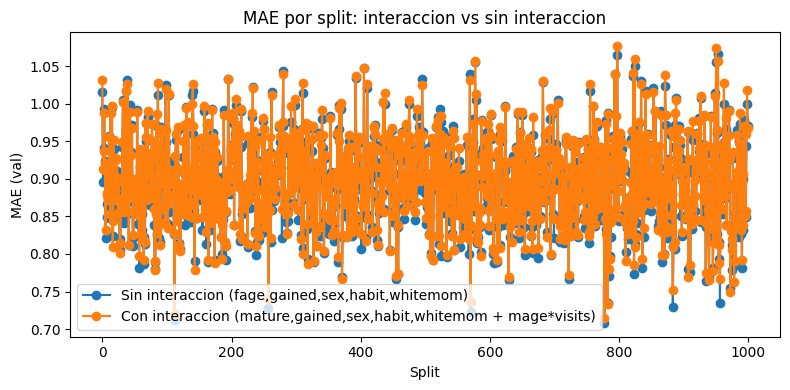

In [23]:
# Comparo la combo sin interaccion (['fage','gained','sex','habit','whitemom'])
# contra la que encontro Tomi con interaccion (['mature','gained','sex','habit','whitemom'] + mage*visits)
# en 10 splits distintos, para ver si la interaccion gana en serio o le toco una seed piola

def evaluate_features_interaction(features, interaction_pairs, X_tr, y_tr, X_val, y_val):
    """
    Como evaluate_features, pero antes de fitear le suma columnas de interaccion
    (producto de dos features numericas) al dataset.
    """
    X_tr_enc, X_val_enc = filter(features, X_tr, X_val)
    X_tr_enc = X_tr_enc.copy()
    X_val_enc = X_val_enc.copy()

    for a, b in interaction_pairs:
        X_tr_enc[f'{a}_x_{b}'] = X_tr[a].values * X_tr[b].values
        X_val_enc[f'{a}_x_{b}'] = X_val[a].values * X_val[b].values

    model = LinearRegression()
    model.fit(X_tr_enc, y_tr)
    preds_val = model.predict(X_val_enc)

    mae = mean_absolute_error(y_val, preds_val)
    r2 = r2_score(y_val, preds_val)
    return mae, r2


no_interaction_features = ['fage', 'gained', 'sex', 'habit', 'whitemom']
interaction_features = ['mature', 'gained', 'sex', 'habit', 'whitemom']
interaction_pairs = [('mage', 'visits')]

n_splits = 1000
rng = np.random.default_rng(0)
rows = []

for split_i in range(n_splits):
    seed = int(rng.integers(0, 1e6))
    X_tr_s, X_val_s, y_tr_s, y_val_s = train_test_split(
        X_train_full, y_train_full, test_size=0.20, random_state=seed
    )

    mae_no, r2_no = evaluate_features(no_interaction_features, X_tr_s, y_tr_s, X_val_s, y_val_s)
    mae_int, r2_int = evaluate_features_interaction(
        interaction_features, interaction_pairs, X_tr_s, y_tr_s, X_val_s, y_val_s
    )

    rows.append({
        'split': split_i,
        'seed': seed,
        'mae_no_interaction': mae_no,
        'mae_interaction': mae_int,
        'interaction_wins': mae_int < mae_no,
        'r2_no_interaction': r2_no,
        'r2_interaction': r2_int,
    })

comparison_df = pd.DataFrame(rows)
comparison_df['mae_diff'] = comparison_df['mae_no_interaction'] - comparison_df['mae_interaction']  # >0 = gano la interaccion

print(comparison_df[['split', 'mae_no_interaction', 'mae_interaction', 'mae_diff', 'interaction_wins']])
print()
print(f"La interaccion gano en {comparison_df['interaction_wins'].sum()} de {n_splits} splits")
print(f"MAE promedio sin interaccion: {comparison_df['mae_no_interaction'].mean():.4f} (+/- {comparison_df['mae_no_interaction'].std():.4f})")
print(f"MAE promedio con interaccion:  {comparison_df['mae_interaction'].mean():.4f} (+/- {comparison_df['mae_interaction'].std():.4f})")

plt.figure(figsize=(8, 4))
plt.plot(comparison_df['split'], comparison_df['mae_no_interaction'], marker='o', label='Sin interaccion (fage,gained,sex,habit,whitemom)')
plt.plot(comparison_df['split'], comparison_df['mae_interaction'], marker='o', label='Con interaccion (mature,gained,sex,habit,whitemom + mage*visits)')
plt.xlabel('Split')
plt.ylabel('MAE (val)')
plt.title('MAE por split: interaccion vs sin interaccion')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Interaccion vs no-interaccion en 10 splits — todo vectorizado, sin pandas/sklearn dentro del loop

no_interaction_features = ['fage', 'gained', 'sex', 'habit', 'whitemom']
interaction_features = ['mature', 'gained', 'sex', 'habit', 'whitemom']

def build_design(features, interaction_pair=None):
    enc = pd.get_dummies(X_train_full[features], drop_first=True)
    if interaction_pair is not None:
        a, b = interaction_pair
        enc[f'{a}_x_{b}'] = X_train_full[a].values * X_train_full[b].values
    X = np.empty((len(enc), enc.shape[1] + 1))
    X[:, 0] = 1.0
    X[:, 1:] = enc.to_numpy(dtype=np.float64)
    return X

X_no = build_design(no_interaction_features)
X_int = build_design(interaction_features, interaction_pair=('mage', 'visits'))
y = y_train_full.to_numpy(dtype=np.float64).ravel()

n_splits = 100000
idx = np.arange(len(y))
rng = np.random.default_rng(0)
rows = []

for split_i in range(n_splits):
    seed = int(rng.integers(0, 1e6))
    itr, ival = train_test_split(idx, test_size=0.20, random_state=seed)
    ytr, yval = y[itr], y[ival]
    ss_tot = ((yval - yval.mean()) ** 2).sum()

    def fit_eval(X):
        Xtr, Xval = X[itr], X[ival]
        beta = np.linalg.solve(Xtr.T @ Xtr, Xtr.T @ ytr)
        res = Xval @ beta - yval
        return np.abs(res).mean(), 1.0 - (res @ res) / ss_tot

    mae_no, r2_no = fit_eval(X_no)
    mae_int, r2_int = fit_eval(X_int)

    rows.append({'split': split_i, 'mae_no_interaction': mae_no, 'mae_interaction': mae_int,
                 'interaction_wins': mae_int < mae_no, 'r2_no_interaction': r2_no, 'r2_interaction': r2_int})

comparison_df = pd.DataFrame(rows)
comparison_df['mae_diff'] = comparison_df['mae_no_interaction'] - comparison_df['mae_interaction']

print(comparison_df[['split', 'mae_no_interaction', 'mae_interaction', 'mae_diff', 'interaction_wins']])
print()
print(f"La interaccion gano en {comparison_df['interaction_wins'].sum()} de {n_splits} splits")
print(f"MAE promedio sin interaccion: {comparison_df['mae_no_interaction'].mean():.4f}")
print(f"MAE promedio con interaccion:  {comparison_df['mae_interaction'].mean():.4f}")

       split  mae_no_interaction  mae_interaction  mae_diff  interaction_wins
0          0            1.016340         1.032418 -0.016078             False
1          1            0.896477         0.913256 -0.016779             False
2          2            0.941482         0.937581  0.003902              True
3          3            0.993154         0.988471  0.004683              True
4          4            0.924445         0.921889  0.002556              True
...      ...                 ...              ...       ...               ...
99995  99995            0.787279         0.788107 -0.000828             False
99996  99996            0.940869         0.924300  0.016569              True
99997  99997            0.810087         0.819674 -0.009586             False
99998  99998            0.882973         0.878506  0.004467              True
99999  99999            0.974440         0.967001  0.007439              True

[100000 rows x 5 columns]

La interaccion gano en 37725 de 1000